In [1]:
!pip install datasets
!pip install evaluate
!pip install fsspec==2023.9.2

#añadido extra
!pip install -U torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.4/173.4 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.9.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 615.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━


⚙️ **Requerimientos importantes sobre el ejercicio**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.



## Imports

In [2]:
import numpy as np
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Add your imports here
from wordcloud import WordCloud
from nltk.corpus import stopwords
import pandas as pd

# 🔍 Ejercicio1: Detección de profesiones en tweets

## Enunciado

En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Utilizaremos un subconjunto de los datos de la tarea 1 del shared task [**ProfNER**](https://temu.bsc.es/smm4h-spanish), centrada en la detección de menciones a profesiones en tweets publicados durante la pandemia del COVID-19. El objetivo original de la tarea era analizar que profesiones podrían haber sido especialmente vulnerables en el contexto de la crisis sanitaria.

Para simplificar el ejercicio, he preparado una versión reducida del dataset original. Tu tarea será entrenar un clasificador binario basado en la arquitectura Transformers, que, dado un tweet, determine si contiene una mención explícita a una profesión (etiqueta `1`) o no (etiqueta `0`).




✅ **Objetivos del ejercicio**

A lo largo de este notebook, completarás las siguientes etapas para construir un clasificador de menciones a profesiones en tweets:

1. **Análisis Exploratorio de Datos (EDA)**: Calcular estadísticas básicas del conjunto de datos (como el número de ejemplos del training set, la distribución de clases del dataset, la longitud media de los textos) o crear visualizaciones para cmprender mejor el contenido de los documentos usando wordclouds o histogramas.

2. **Selección y justificación del modelo**: Elegir un modelo del Hub de Huggingface adecuado para los datos con los que se va a trabajar y el tipo de tarea a desarrollar.

3. **Entrenamiento del clasificador**: Entrenar el modelo de forma reproducible y evaluar su rendimiento sobreel conjunto de datos de validación, incluyendo un classification score y matriz de confusion

4. **Generación de predicciones sobre el conjunte de test**: Aplicar el modelo entrenado al conjunto de test, y guardar las predicciones en un archivo `.tsv` de 2 columnas `id` y `label` separadas por tabulador

📝 **Criterios de Evaluación**

Tu trabajo será evaluado según los siguientes criterios:

| Criterio                                            | Peso  |
|-----------------------------------------------------|--------|
| 🔍 Análisis exploratorio y preprocesamiento         | 20%   |
| 🤖 Selección y justificación del modelo             | 25%   |
| 📁 Formato y validez del archivo de predicciones    | 5%    |
| ⚙️ Ejecución correcta del notebook (sin intervención) | 10%   |
| 📈 Rendimiento del modelo sobre el conjunto de test | 30%   |
| ✍️ Claridad y calidad de las explicaciones          | 10%   |



🔔 **Nota importante:**

> El rendimiento del modelo se evaluará utilizando métricas estándar como el **F1-score** sobre el conjunto de test.

> El archivo de predicciones debe respetar **estrictamente** el formato solicitado (`id` y `label`, separados por tabulador y con extensión `.tsv`).  
  ❗ Si el archivo no cumple con este formato, **el ejercicio no podrá ser evaluado en esa sección**.

> El/la estudiante con el **mayor F1-score** obtendrá la puntuación máxima en el apartado de rendimiento. El resto de calificaciones se ajustarán de forma proporcional al mejor resultado



⚙️ **Requerimientos y reglas**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.


# Tu resolución (rellena las celdas marcadas)

## Obtención de datos

Descargamos los datos del [repositorio de Huggingface](https://huggingface.co/datasets/luisgasco/profner_classification_master).

In [4]:
#NO-MODIFY: DATA LOAD
from datasets import load_dataset, Dataset, DatasetDict, ClassLabel
dataset = load_dataset("luisgasco/profner_classification_master")

README.md:   0%|          | 0.00/2.83k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/480k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/162k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2786 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1001 [00:00<?, ? examples/s]

El dataset contiene tres subsets:
- **train** y **validation**: Contienen el identificador del tweet, el texto, y su etiqueta, que podrá tener valor 1, si contiene una mención de una profesión; o valor 0, si no contiene una mención de una profesión.
- **test**: El test set tambiíen contiene la información de label por un requerimiento de Huggingface, pero el contenido de esta variable es siempre "-1". Es decir que deberéis predecir nuevas etiquetas una vez hayáis entrenado el modelo utilizando el train y el validation set.

## Análisis exploratorio de datos

Para hacer el análisis exploratorio de datos, transformamos cada subset a un pandas dataframe para mayor comodidad.

In [5]:
#NO-MODIFY: DATA LOAD
dataset_train_df = dataset["train"].to_pandas()
dataset_val_df = dataset["validation"].to_pandas()
dataset_test_df = dataset["test"].to_pandas()

**Número de documentos**

Obten con la función `get_num_docs_evaluation()` el número de documentos del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [6]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def get_num_docs_evaluation(dataset_df):
  # Modifica la función.
  num_docs = len(dataset_df)

  # No modifiques el return
  return num_docs

Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [7]:
# Aplica la función
num_train = get_num_docs_evaluation(dataset_train_df)
num_val = get_num_docs_evaluation(dataset_val_df)

print(f"Número de documentos en train: {num_train}")
print(f"Número de documentos en validation: {num_val}")

Número de documentos en train: 2786
Número de documentos en validation: 999


EL conjunto de datos tiene 2786 en train y 999 en validacion, lo cual se considera un tamaño suficiente para entrenar y evaluar el modelo adecuadamente.

**Número de documentos duplicados**

Obten con la función `detect_duplicates_evaluation()` el número de documentos duplicados del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro de la siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [8]:
def detect_duplicates_evaluation(dataset_df):
  # Modifica la función.
  num_duplicates = dataset_df["tweet_id"].duplicated().sum()

  # No modifiques el return
  return num_duplicates

Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [9]:
# Aplica la función
print("Duplicados en train:", detect_duplicates_evaluation(dataset_train_df))
print("Duplicados en validation:", detect_duplicates_evaluation(dataset_val_df))

Duplicados en train: 0
Duplicados en validation: 0


No se han detecatado documentos duplicados lo que evita el tratamiento y eliminacion de los mismos y reduce el riesgo de introducir posibles sesgos.

**Número de documentos por cada clase:**


Obten con la función `analyse_num_labels_evaluation()` para calcular el número de documentos de cada categoría en el dataset

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [10]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def analyse_num_labels_evaluation(dataset_df):
  # Modifica la función.
  num_positives = (dataset_df["label"] == 1).sum()
  num_negatives = (dataset_df["label"] == 0).sum()

  # No modifiques el return
  return num_positives, num_negatives

Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [11]:
# Aplica la función
num_pos_train, num_neg_train = analyse_num_labels_evaluation(dataset_train_df)

print("Positivos:", num_pos_train)
print("Negativos:", num_neg_train)

Positivos: 1393
Negativos: 1393


Ls distribucion entre las dos clases esta equilibrada y no es necesario balancearla para que el modelo entrene correctamente.

**Distribución de la longitud de los tweet en caracteres:**

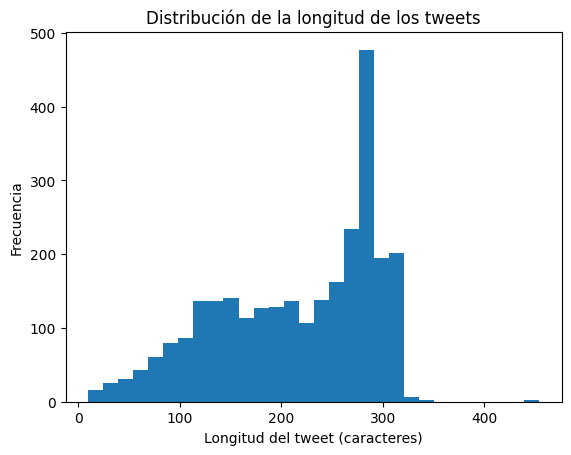

In [12]:
dataset_train_df["tweet_length"] = dataset_train_df["text"].str.len()
dataset_train_df["tweet_length"].describe()

import matplotlib.pyplot as plt

plt.hist(dataset_train_df["tweet_length"], bins=30)
plt.xlabel("Longitud del tweet (caracteres)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la longitud de los tweets")
plt.show()

In [13]:
dataset_train_df["tweet_length"].describe()

,tweet_length
count,2786.000000
mean,215.057430
std,77.171112
min,10.000000
25%,152.000000
50%,235.000000
75%,282.000000
max,454.000000


La longitud de la mayoria de lo tweets esta comprendida entre 150 y 300, con una media de 215 caracteres.

**Análisis de contenido de los tweets**

Para ello utiliza wordclouds

In [14]:
spanish_stopwords = set(stopwords.words('spanish'))

custom_stopwords = spanish_stopwords.union({
    "https",
    "covid",
    "covid19",
    "coronavirus",
    "pandemia",
    "t",
    "co",
    "si",
    "hoy",
    "día",
    "cómo"
})

txt_label0 = " ".join(
    dataset_train_df[dataset_train_df["label"] == 0]["text"]
    .astype(str)
    .str.lower()
    .tolist()
)

txt_label1 = " ".join(
    dataset_train_df[dataset_train_df["label"] == 1]["text"]
    .astype(str)
    .str.lower()
    .tolist()
)

wordcloud = WordCloud(
    background_color="white",
    max_words=5000,
    contour_width=0,
    contour_color='steelblue',
    stopwords=custom_stopwords,
    normalize_plurals = True)

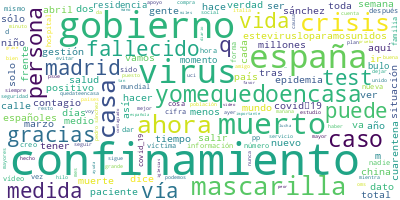

In [15]:
# Genera el wordcloud
wordcloud.generate(txt_label0)
# Visualizalo en una imagen
wordcloud.to_image()

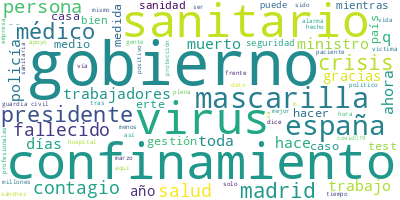

In [16]:
# Genera el wordcloud
wordcloud.generate(txt_label1)
# Visualizalo en una imagen
wordcloud.to_image()

Los dos wordclous muestran palabras relacionadas con la pandemia ya que el dataset esta centrado en el COVID-19. En el de la clase 1 aparecen algunas profesiones como sanitario o medico, lo cual es esperado en esta clase de tweets.

## Tokenización

El texto del dataset no está preparado para ser introducido en un modelo Transformers. Lleva a cabo el proceso de tokenización.

In [17]:
from transformers import AutoTokenizer

Selecciona un modelo apropiado para la tarea:

> Recuerda que en la siguiente celda sólo debes asignar un valor a model_name. No añadas más información en la celda.

In [18]:
#NO-MODIFY: VARIABLE NAME
model_name = 'PlanTL-GOB-ES/bsc-bio-es'

Seleccionamos el modelo 'PlanTL-GOB-ES/bsc-bio-es' porque está preentrenado en español, utiliza
una arquitectura encoder adecuada para hacer clasificación y su preentrenamiento esta hecho en el ambito biomedico, lo cual es apropiado para un dataset relacionado con la COVID-19
.

Puedes continuar con el proceso aquí:

In [19]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False
)

tokens = tokenizer.tokenize(dataset_train_df["text"].iloc[0])

print(tokens)

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.18M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/523k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

['ĠLas', 'Ġ/', 'Ġos', 'Ġsanitarias', 'Ġ/', 'Ġos', 'Ġno', 'Ġnecesitan', 'Ġcapas', 'Ġde', 'Ġsuperh', 'Ã©roes', 'Ġy', 'Ġsuperh', 'ero', 'ÃŃnas', 'Ġ', ',', 'Ġnecesitan', 'Ġfondos', 'Ġsuficientes', 'Ġpara', 'Ġlos', 'ĠEPI', 'Ġque', 'Ġdeben', 'Ġusar', 'Ġ', ',', 'Ġpara', 'Ġrespir', 'adores', 'Ġ.', '.', '.', 'ĠE', 'xi', 'j', 'Ã¡', 'mos', 'lo', 'ĠðŁ', '§', 'ĳ', 'ĠðŁ', 'ı', '»', 'âĢ', 'į', 'Ġâ', 'ļ', 'ķ', 'Ġï', '¸', 'ı', 'ĠðŁ', 'ĳ', '©', 'ĠðŁ', 'ı', '»', 'âĢ', 'į', 'Ġâ', 'ļ', 'ķ', 'Ġï', '¸', 'ı', 'ĠðŁ', 'ĳ', '¨', 'ĠðŁ', 'ı', '»', 'âĢ', 'į', 'Ġâ', 'ļ', 'ķ', 'Ġï', '¸', 'ı', 'Ġ#', 'ĠMF', 'yC', 'Ġ#', 'ĠCO', 'VID', '19', 'Ġ#', 'ĠDespuÃ©s', 'De', 'A', 'pla', 'u', 'dir', 'Ġhttps', '://', 't', '.', 'co', '/', 'liz', 'Z', 'E', 'Y', 'p', '5', 'J', 'j']


In [20]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_train = dataset["train"].map(tokenize_function, batched=True)
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_train.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

tokenized_validation = dataset["validation"].map(tokenize_function, batched=True)
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_validation.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Map:   0%|          | 0/2786 [00:00<?, ? examples/s]

Map:   0%|          | 0/999 [00:00<?, ? examples/s]

## Fine-tuning

Carga el model para ser ajustado posteriormente:

In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-es
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Configuracion training_args

Configura los parámetros de entrenamiento del modelo.


>

> Recuerda que en la siguiente celda sólo debes asignar atributos a la variable training_args. No añadas  otras variables en la celda

In [22]:
#NO-MODIFY: VARIABLE NAME
#training_args = TrainingArguments(
#)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_model1",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    seed=52
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Los parámetros de entrenamiento determinan cómo se ajustará el modelo durante el fine-tuning. En este caso realizamos 3 épocas de entrenamiento, utilizando lotes de 8 ejemplos, y aplicando una fase de warm-up y una regularización (weight decay) para mejorar el aprendizaje, y se fija una semilla para garantizar la reproducibilidad de los resultados.






### Métricas de evaluación

Define las métricas de evaluación

In [23]:
import evaluate

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],
        "precision": precision.compute(
            predictions=predictions,
            references=labels
        )["precision"],
        "recall": recall.compute(
            predictions=predictions,
            references=labels
        )["recall"],
        "f1": f1.compute(
            predictions=predictions,
            references=labels
        )["f1"],
    }

### Ajuste del modelo

Lleva a cabo el ajuste del modelo:

In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss
10,0.698600
20,0.686499
30,0.702580
40,0.698811
50,0.684121
60,0.668926
70,0.671447
80,0.682980
90,0.691653
100,0.683137


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1047, training_loss=0.28332848442716607, metrics={'train_runtime': 299.1773, 'train_samples_per_second': 27.937, 'train_steps_per_second': 3.5, 'total_flos': 549770550174720.0, 'train_loss': 0.28332848442716607, 'epoch': 3.0})

## Evaluacion

Una vez llevada a cabo el entrenamiento, realiza la evaluación del modelo.

In [26]:
results_model1 = trainer.evaluate()

print("Accuracy:", results_model1["eval_accuracy"])
print("Precision:", results_model1["eval_precision"])
print("Recall:", results_model1["eval_recall"])
print("F1:", results_model1["eval_f1"])

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.191175,0.333368,1047,0.930931,0.798587,0.949580,0.867562


Accuracy: 0.9309309309309309
Precision: 0.7985865724381626
Recall: 0.9495798319327731
F1: 0.8675623800383877


Se obtiene una accuracy de 0.93 y un F1-score de 0.86 lo cual indica buen rendimiento. Por otro lado, el recall es superior a la precision lo que indica que la mayoria de los tweets tienen profesiones aunque hay algunos falsos positivos.

In [27]:
from sklearn.metrics import classification_report

predictions = trainer.predict(tokenized_validation)
pred_labels = predictions.predictions.argmax(axis=-1)

print(classification_report(
    tokenized_validation["labels"],
    pred_labels
))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       761
           1       0.80      0.95      0.87       238

    accuracy                           0.93       999
   macro avg       0.89      0.94      0.91       999
weighted avg       0.94      0.93      0.93       999



En ambas clases obtenemos buen rendimiento, el modelo identifica correctamente los tweets que contienen profesiones (clase 1) con un recall de 0.95, aunque algunos tweets que no mencionan profesiones hacen de falso positivo, con una precision de 0.80, como consecuencia obtenemos un f1-score de 0.87 reflejando el equilibrio entre ambas.

## Genera predicciones

In [28]:
# Tokenización del conjunto de test
tokenized_test = dataset["test"].map(
    tokenize_function,
    batched=True
)

# Sustituimos las etiquetas -1 por un valor válido para evitar errores en Trainer.predict()
def fix_labels(example):
    if example["label"] == -1:
        example["label"] = 1
    return example

tokenized_test = tokenized_test.map(fix_labels)

tokenized_test = tokenized_test.rename_column("label", "labels")

tokenized_test.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

tokenized_test

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Dataset({
    features: ['tweet_id', 'text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 1001
})

In [29]:
predictions = trainer.predict(tokenized_test)

pred_labels = predictions.predictions.argmax(axis=-1)

Genera predicciones sobre el test set. Recuerda que el archivo que generes y adjuntes al ejercicio debe tener dos columnas:


| id         | label |
|------------|-------|
| 1234567890 | 1     |
| 1234567891 | 0     |
| 1234567892 | 0     |
| 1234567893 | 1     |

- El archivo debe estar en formato **TSV** (separado por tabuladores).
- Debe contener exactamente **dos columnas**: `id` y `label`.
- Es obligatorio incluir la **cabecera**.


In [30]:
submission = pd.DataFrame({
    "id": dataset_test_df["tweet_id"],
    "label": pred_labels
})

submission.to_csv(
    "predicciones.tsv",
    sep="\t",
    index=False
)

submission.head()

,id,label
0,1277969650051997701,1
1,1263161378627600385,0
2,1255919996779315208,0
3,1282361712117780486,0
4,1267872916009615364,0


### Prueba de otros modelos